## WORKING ON A CNN Model:



Given the Eye-Gender dataset, build a deep learning model to predict the gender of the person given the image of the eye.

# Step 1 Importing Libraries

In [ ]:
import cv2
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Step 2: Loading the Dataset

In [6]:
df = pd.read_csv(r"C:\Users\salim\Documents\SCHOOL STUFF\RAIN\RDA 212\Deep Learning\EXAMS\eye_gender_data\Training_set.csv") 

In [7]:
df.head()

,filename,label
0,Image_1.jpg,male
1,Image_2.jpg,female
2,Image_3.jpg,female
3,Image_4.jpg,female
4,Image_5.jpg,male


In [9]:
df.shape

(9220, 2)

In [10]:
train_path = (r"C:\Users\salim\Documents\SCHOOL STUFF\RAIN\RDA 212\Deep Learning\EXAMS\eye_gender_data\train")

In [11]:
os.listdir(train_path)[:5]

['Image_1.jpg',
 'Image_10.jpg',
 'Image_100.jpg',
 'Image_1000.jpg',
 'Image_1001.jpg']

# Step 3: Preprocessing the Image / Dataset

In [12]:
cv2.imread(r"C:\Users\salim\Documents\SCHOOL STUFF\RAIN\RDA 212\Deep Learning\EXAMS\eye_gender_data\train\Image_1.jpg")

array([[[188, 188, 188],
        [189, 189, 189],
        [190, 190, 190],
        ...,
        [180, 180, 180],
        [177, 177, 177],
        [175, 175, 175]],

       [[190, 190, 190],
        [187, 187, 187],
        [185, 185, 185],
        ...,
        [173, 173, 173],
        [167, 167, 167],
        [165, 165, 165]],

       [[189, 189, 189],
        [182, 182, 182],
        [179, 179, 179],
        ...,
        [172, 172, 172],
        [165, 165, 165],
        [161, 161, 161]],

       ...,

       [[136, 136, 136],
        [148, 148, 148],
        [150, 150, 150],
        ...,
        [164, 164, 164],
        [165, 165, 165],
        [163, 163, 163]],

       [[133, 133, 133],
        [146, 146, 146],
        [151, 151, 151],
        ...,
        [170, 170, 170],
        [169, 169, 169],
        [167, 167, 167]],

       [[135, 135, 135],
        [148, 148, 148],
        [156, 156, 156],
        ...,
        [166, 166, 166],
        [164, 164, 164],
        [162, 162, 162]]

To  read, resize and normalize the image and normalize the image values


In [ ]:
X = []    #This would be for the image arrays
y = []   #This would be for labels 

for r, row in df.iterrows():
    filename = row["filename"]   
    label    = row["label"]     
    img_path = os.path.join(train_path, filename)

    try:
        img = cv2.imread(img_path)
        img = cv2.resize(img, (60, 60))
        img = img / 255.0   #To normalize the data and reduce the range of values for each pixel for easier calculation and increases training speed
        X.append(img)
        # Converting text labels to numbers: female=0, male=1
        if label.lower() == "male":
            y.append(1)
        else:
            y.append(0)
    except:
        pass


Comparing the size of X and Y

In [14]:
len (X)

9220

In [16]:
len(y)

9220

# Step 4: Convert to NumPy Array for Python Analysis


In [ ]:
X_arr = np.array(X)


In [22]:
y_arr = np.array(y)

In [20]:
X_arr.shape

(9220, 60, 60, 3)

In [21]:
y_arr.shape

(9220,)

# Stage 5: Visualizing the Images before Training

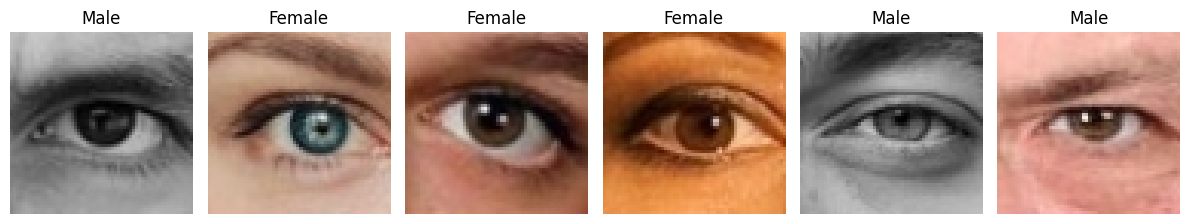

In [ ]:
female_label = 0
male_label = 1

plt.figure(figsize=(12, 4))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(cv2.cvtColor((X_arr[i] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    plt.title("Female" if y_arr[i] == female_label else "Male")
    plt.axis("off")
plt.tight_layout()
plt.show()

# Step 6: Splitting the DAtaset into Train and Test Set

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_arr,
    y_arr,
    test_size=0.3, # this allows 30% of the data to be used for test and 70% to train data
    random_state=9 
)

Training samples: 6454
Testing samples:  2766


In [31]:
len(X_train)


6454

In [29]:
len(y_train)

6454

In [32]:
len(X_test)

2766

In [33]:
len(y_test)

2766

# Step 7: Model Building

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(60, 60, 3)))
model.add(MaxPooling2D(2, 2))  
model.add(Conv2D(64, (3, 3), activation="relu")) 
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Flatten()) 
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5)) #this will be to reduce overfitting
model.add(Dense(1, activation="sigmoid")) #since it is binary classification
#to view the structure of the model
model.summary()

c:\Users\salim\anaconda3\envs\my_opencv_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 58, 58, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,105 (1.92 MB)

 Trainable params: 503,105 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

# Step 8: Model Compilation

In [35]:
model.compile( loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"] )

# Step 9: Model Training

In [36]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    verbose=1,
    validation_split=0.2 #I'm using 20% of training data for validation
    )

Epoch 1/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.6853 - loss: 0.5756 - val_accuracy: 0.8133 - val_loss: 0.4313
Epoch 2/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.8232 - loss: 0.4044 - val_accuracy: 0.8319 - val_loss: 0.3496
Epoch 3/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.8627 - loss: 0.3302 - val_accuracy: 0.8311 - val_loss: 0.3535
Epoch 4/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8805 - loss: 0.2808 - val_accuracy: 0.9086 - val_loss: 0.2445
Epoch 5/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - accuracy: 0.8935 - loss: 0.2616 - val_accuracy: 0.8885 - val_loss: 0.2649
Epoch 6/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 128ms/step - accuracy: 0.9057 - loss: 0.2345 - val_accuracy: 0.9078 - val_loss: 0.2447
Epoch 7/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 140ms/step - accuracy: 0.9154 - loss: 0.2098 - val_accuracy: 0.9024 - val_loss: 0.2436
Epoch 8/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.9229 - loss: 0.200

# Step 10: Train History Graph

This is to see how the accuracy and loss appear over the epochs and to see how well the model learnt

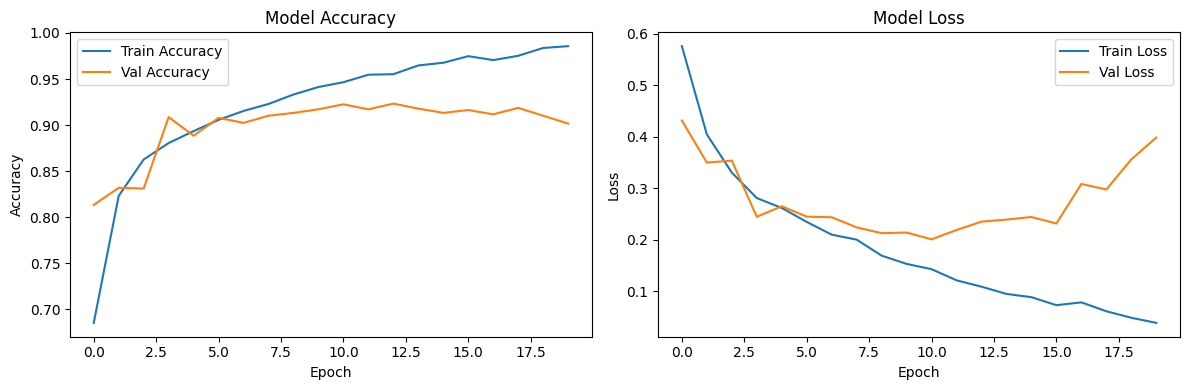

In [37]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

plt.show()

# Step 11: Using the Test Set to Evaluate the Accuracy of the Model

In [38]:
test_loss, test_accuracy = model.evaluate(X_test,y_test, verbose = 0)

In [39]:
test_loss

0.39171627163887024

In [40]:
test_accuracy

0.9067245125770569

In [41]:
model.save("gender_eye_classification_model.keras")
print("Model saved successfully!")

Model saved successfully!
